#### DWD Mean sunshine duration,  air temperature  data, and precipitation of Germany

#### Setup for EDA 

In [1114]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
##
##
import glob
import json
import re
import os
##

## Plotting Functions

In [1115]:
def simple_lineplot(df, y, x="Date"):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax,  marker="o")
    #ax.set(title= main_title, ylabel=y)
    ax.set(ylabel=y)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [1116]:
def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ax.set(title=main_title, ylabel=y);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax)
    ax.set(title=main_title, ylabel=y);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

## Data overview

###  Monthly sunshine-duration and air-temperature-mean 

- ../data/sunshine-duration-monthly

- ../data/air-temperature-monthly

### Paths to 'target' data folders

- sunshine-duration_  = '../data/sunshine-duration-monthly'
- air-temperature_  = '../data/air-temperature-monthly'
- precipitation_  = '../data/air-temperature-monthly'


In [1117]:
sunshine_duration_  = 'data/sunshine-duration-monthly/*.txt'
air_temperature_  = 'data/air-temperature-monthly/*.txt'
precipitation_ = 'data/precipitation/*.txt'

#sunshine_duration_  = '../data/sunshine-duration-monthly/*.txt'
#air_temperature_  = '../data/air-temperature-monthly/*.txt'
#precipitation_ = '../data/precipitation/*.txt'

### Importing available data for monthly 'mean sunshine duration'  for individual states and Germany.

In [1118]:
# Get a list of all CSV files in a directory
# Sorted will append files in 
txt_files =  sorted(glob.glob(sunshine_duration_), reverse=False)

# Create an empty list to store the data from each txt file
pattern = ';'
main_SD_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, skiprows=1, sep = pattern, engine='python')#'ISO-8859-1')
    print(file, df.shape)
    # Append the DataFrame to the list
    main_SD_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
SD_df_monthly = pd.concat(main_SD_df, ignore_index=False).reset_index(drop=True) #SD_df_monthly  = pd.concat(main_SD_df, axis=1)
#SD_df_monthly.to_csv('../data/sunshine-duration-monthly/SD_df_monthly.csv')
#SD_df_monthly.to_csv('../data/sunshine-duration-monthly/SD_df_monthly.csv')

data/sunshine-duration-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_sunshine_duration_regional_averages_sd_01.txt (73, 20)
data/sunshine-duration-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_sunshine_duration_regional_averages_sd_02.txt (73, 20)
data/sunshine-duration-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_sunshine_duration_regional_averages_sd_03.txt (73, 20)
data/sunshine-duration-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_sunshine_duration_regional_averages_sd_04.txt (73, 20)
data/sunshine-duration-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_sunshine_duration_regional_averages_sd_05.txt (73, 20)
data/sunshine-duration-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_sunshine_duration_regional_averages_sd_06.txt (73, 20)
data/sunshine-duration-monthly/opendata.dwd.de_climate_environment_CDC

In [1119]:
SD_df_monthly.columns, SD_df_monthly.shape

(Index(['Jahr', 'Monat', 'Brandenburg/Berlin', 'Brandenburg',
        'Baden-Wuerttemberg', 'Bayern', 'Hessen', 'Mecklenburg-Vorpommern',
        'Niedersachsen', 'Niedersachsen/Hamburg/Bremen', 'Nordrhein-Westfalen',
        'Rheinland-Pfalz', 'Schleswig-Holstein', 'Saarland', 'Sachsen',
        'Sachsen-Anhalt', 'Thueringen/Sachsen-Anhalt', 'Thueringen',
        'Deutschland', 'Unnamed: 19'],
       dtype='object'),
 (870, 20))

In [1120]:
SD_df_monthly.head()

,Jahr,Monat,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland,Unnamed: 19
0,1951,1,45.2,45.3,30.6,34.5,22.8,39.7,24.4,24.6,23.3,23.9,35.8,21.5,37.6,28.0,26.0,23.5,30.9,NaN
1,1952,1,38.9,39.0,39.1,39.3,19.3,38.1,25.9,26.0,23.3,27.0,38.1,15.2,41.9,35.0,30.7,25.3,33.0,NaN
2,1953,1,15.3,15.3,36.8,30.8,20.5,17.7,16.2,16.2,19.6,31.7,18.4,42.7,20.8,13.7,16.6,20.3,23.2,NaN
3,1954,1,81.0,81.1,54.7,71.1,80.4,81.9,80.9,81.1,80.2,80.4,85.4,83.9,66.5,71.1,68.9,66.1,74.5,NaN
4,1955,1,71.7,71.6,60.4,65.6,46.1,53.9,49.3,49.4,40.1,43.5,46.0,44.4,89.9,65.1,63.3,61.0,57.9,NaN


In [1121]:
def arrange_data_by_year_and_month_DE(input_df):
    # Sort the DataFrame by 'Year' and 'Month'
    input_df.sort_values(by=['Jahr', 'Monat'], inplace=True)
    # Reset the index after sorting
    input_df.reset_index(drop=True, inplace=True)
    return input_df
arrange_data_by_year_and_month_DE(SD_df_monthly)


,Jahr,Monat,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland,Unnamed: 19
0,1951,1,45.2,45.3,30.6,34.5,22.8,39.7,24.4,24.6,23.3,23.9,35.8,21.5,37.6,28.0,26.0,23.5,30.9,NaN
1,1951,2,67.0,67.2,65.9,63.7,49.7,56.1,44.6,44.5,52.1,59.1,37.5,59.8,80.6,50.2,50.5,50.9,57.3,NaN
2,1951,3,129.5,129.5,96.3,98.9,114.6,117.4,114.6,114.9,105.0,107.3,117.9,110.3,116.9,118.1,115.7,112.7,110.1,NaN
3,1951,4,227.3,227.4,195.6,198.0,189.0,226.3,185.3,185.4,180.3,187.5,189.3,196.8,223.6,208.2,204.0,198.7,199.1,NaN
4,1951,5,195.3,195.5,197.8,192.2,202.7,244.1,211.1,211.5,203.8,205.3,243.9,216.2,200.5,180.5,182.2,184.4,203.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,2023,2,76.8,76.8,109.5,97.0,88.4,77.6,86.3,86.2,92.6,105.1,74.3,113.0,71.4,76.9,78.1,79.7,89.2,NaN
866,2023,3,97.0,96.8,118.2,114.3,92.9,102.1,86.9,86.9,85.2,101.7,98.0,103.6,94.6,90.1,90.2,90.3,99.7,NaN
867,2023,4,149.1,148.9,127.6,129.3,145.9,183.5,178.7,179.1,154.4,149.2,213.9,147.5,127.0,153.3,146.7,138.2,151.0,NaN
868,2023,5,296.6,296.1,209.5,226.3,248.0,305.3,241.3,241.4,237.4,250.9,261.1,266.5,269.6,269.6,262.4,253.0,249.3,NaN


In [1122]:
#columns_to_drop_SD = ['Brandenburg/Berlin', 'Brandenburg', 'Baden-Wuerttemberg', 'Bayern', 'Hessen', 'Mecklenburg-Vorpommern',
#                   'Niedersachsen', 'Niedersachsen/Hamburg/Bremen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz',
#                   'Schleswig-Holstein', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Thueringen/Sachsen-Anhalt',
#                   'Thueringen', 'Unnamed: 19']
#Sun_df_DE = SD_df_monthly.drop(columns=columns_to_drop_SD, inplace=True)
columns_to_keep_SD = ['Jahr', 'Monat', 'Deutschland']
Sun_df_DE = SD_df_monthly[columns_to_keep_SD].copy()
Sun_df_DE.head()

,Jahr,Monat,Deutschland
0,1951,1,30.9
1,1951,2,57.3
2,1951,3,110.1
3,1951,4,199.1
4,1951,5,203.3


In [1123]:
# Create a dictionary to map the old column names to the new ones
column_name_mapping_SD = {
    'Jahr': 'Year',
    'Monat': 'Month',
    'Deutschland': 'Mean_sunshine_duration_DE'
}
# Use the rename method to rename the columns
Sun_df_DE.rename(columns=column_name_mapping_SD, inplace=True)
Sun_df_DE.head()

,Year,Month,Mean_sunshine_duration_DE
0,1951,1,30.9
1,1951,2,57.3
2,1951,3,110.1
3,1951,4,199.1
4,1951,5,203.3


#### We create  a new dataframe for mean sunshine duration f Germany from 2015 to 2023

In [1124]:
start_year = 2015
end_year = 2023
filtered_data_SD = Sun_df_DE[(Sun_df_DE['Year'] >= start_year) & (Sun_df_DE['Year'] <= end_year)]
# Create a new DataFrame with the filtered data and only the required columns
SunD_15to23= filtered_data_SD[['Year', 'Month', 'Mean_sunshine_duration_DE']]
SunD_15to23_df= pd.DataFrame(SunD_15to23)
SunD_15to23_df.reset_index(drop=True, inplace=True)

In [1125]:
SunD_15to23_df.head(100),SunD_15to23_df.shape

(    Year  Month  Mean_sunshine_duration_DE
 0   2015      1                       35.3
 1   2015      2                       88.0
 2   2015      3                      139.1
 3   2015      4                      224.5
 4   2015      5                      187.0
 ..   ...    ...                        ...
 95  2022     12                       38.8
 96  2023      1                       32.2
 97  2023      2                       89.2
 98  2023      3                       99.7
 99  2023      4                      151.0
 
 [100 rows x 3 columns],
 (102, 3))

In [1126]:
#def arrange_data_by_year_and_month(input_df):
#    # Sort the DataFrame by 'Year' and 'Month'
#    input_df.sort_values(by=['Year', 'Month'], inplace=True)
    # Reset the index after sorting
#    input_df.reset_index(drop=True, inplace=True)
#    return input_df
#arrange_data_by_year_and_month(SunD_15to23_df)


###  Importing available data for monthly 'mean air temperature' for individual states and Germany.

In [1127]:
# Get a list of all CSV files in a directory
# Sorted will append files in 
txt_files =  sorted(glob.glob(air_temperature_), reverse=False)

# Create an empty list to store the data from each txt file
pattern = ';'
main_AT_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, skiprows=1, sep = pattern, engine='python')#'ISO-8859-1')
    print(file, df.shape)
    # Append the DataFrame to the list
    main_AT_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
AT_df_monthly = pd.concat(main_AT_df, ignore_index=False).reset_index(drop=True) #AT_df_monthly = pd.concat(main_AT_df, axis=1)
#AT_df_monthly.to_csv('../data/AT_df_monthly.csv')

data/air-temperature-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_air_temperature_mean_regional_averages_tm_01.txt (143, 20)
data/air-temperature-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_air_temperature_mean_regional_averages_tm_02.txt (143, 20)
data/air-temperature-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_air_temperature_mean_regional_averages_tm_03.txt (143, 20)
data/air-temperature-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_air_temperature_mean_regional_averages_tm_04.txt (143, 20)
data/air-temperature-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_air_temperature_mean_regional_averages_tm_05.txt (143, 20)
data/air-temperature-monthly/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_air_temperature_mean_regional_averages_tm_06.txt (143, 20)
data/air-temperature-monthly/opendata.dwd.de_climate_envir

In [1128]:
AT_df_monthly.columns, AT_df_monthly.shape

(Index(['Jahr', 'Monat', 'Brandenburg/Berlin', 'Brandenburg',
        'Baden-Wuerttemberg', 'Bayern', 'Hessen', 'Mecklenburg-Vorpommern',
        'Niedersachsen', 'Niedersachsen/Hamburg/Bremen', 'Nordrhein-Westfalen',
        'Rheinland-Pfalz', 'Schleswig-Holstein', 'Saarland', 'Sachsen',
        'Sachsen-Anhalt', 'Thueringen/Sachsen-Anhalt', 'Thueringen',
        'Deutschland', 'Unnamed: 19'],
       dtype='object'),
 (1710, 20))

In [1129]:
AT_df_monthly.head()

,Jahr,Monat,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland,Unnamed: 19
0,1881,1,-5.54,-5.56,-4.89,-6.51,-5.68,-5.07,-4.55,-4.55,-4.21,-4.49,-4.06,-4.15,-6.22,-5.89,-6.28,-6.76,-5.36,NaN
1,1882,1,1.43,1.42,-0.65,-1.33,-0.30,1.59,1.73,1.73,1.26,-0.17,2.11,-0.04,0.63,1.18,0.60,-0.12,0.41,NaN
2,1883,1,-0.41,-0.42,-0.09,-1.49,0.04,-0.69,0.33,0.32,1.27,0.49,-0.12,0.55,-1.20,-0.39,-0.69,-1.07,-0.32,NaN
3,1884,1,3.35,3.34,2.34,1.22,2.97,3.16,3.99,3.99,4.17,3.24,3.56,3.24,2.39,3.32,2.93,2.43,2.86,NaN
4,1885,1,-2.15,-2.16,-3.88,-4.91,-2.66,-1.71,-1.44,-1.44,-1.14,-2.01,-1.09,-2.00,-2.87,-2.86,-3.36,-3.98,-2.79,NaN


In [1130]:
arrange_data_by_year_and_month_DE(AT_df_monthly)

,Jahr,Monat,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland,Unnamed: 19
0,1881,1,-5.54,-5.56,-4.89,-6.51,-5.68,-5.07,-4.55,-4.55,-4.21,-4.49,-4.06,-4.15,-6.22,-5.89,-6.28,-6.76,-5.36,NaN
1,1881,2,-1.00,-1.01,1.33,-0.73,0.75,-2.01,-0.05,-0.07,1.64,1.45,-1.81,2.25,-0.92,-0.42,-0.34,-0.25,-0.10,NaN
2,1881,3,1.71,1.70,4.42,2.50,3.43,0.40,2.20,2.19,3.81,4.49,0.54,5.37,1.79,2.20,2.18,2.14,2.61,NaN
3,1881,4,5.56,5.55,6.63,5.01,5.88,4.63,5.64,5.64,6.44,6.65,5.02,7.08,4.41,5.51,5.04,4.43,5.55,NaN
4,1881,5,12.85,12.83,11.44,10.99,12.15,11.58,12.03,12.03,12.55,12.25,11.16,12.38,11.49,12.57,12.05,11.40,11.81,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,2023,2,2.98,2.97,2.82,1.89,3.39,3.04,4.31,4.32,4.65,3.99,4.04,4.25,2.43,3.51,3.09,2.55,3.21,NaN
1706,2023,3,5.59,5.58,6.23,5.44,5.83,5.12,5.90,5.90,6.30,6.32,5.32,6.57,5.29,5.90,5.59,5.19,5.74,NaN
1707,2023,4,7.80,7.79,7.54,6.85,7.68,7.18,8.02,8.02,8.17,8.12,7.42,8.46,6.98,7.84,7.41,6.84,7.53,NaN
1708,2023,5,13.61,13.59,13.33,13.06,13.28,12.60,12.81,12.82,13.27,13.72,12.07,14.33,12.73,13.42,13.00,12.46,13.08,NaN


In [1131]:
columns_to_keep_AT = ['Jahr', 'Monat', 'Deutschland']
AT_df_DE = AT_df_monthly[columns_to_keep_AT].copy()
AT_df_DE.head()

,Jahr,Monat,Deutschland
0,1881,1,-5.36
1,1881,2,-0.10
2,1881,3,2.61
3,1881,4,5.55
4,1881,5,11.81


In [1132]:
# Create a dictionary to map the old column names to the new ones
column_name_mapping_AT = {
    'Jahr': 'Year',
    'Monat': 'Month',
    'Deutschland': 'Mean_air_temperature_DE'
}

# Use the rename method to rename the columns
AT_df_DE.rename(columns=column_name_mapping_AT, inplace=True)
AT_df_DE.head()

,Year,Month,Mean_air_temperature_DE
0,1881,1,-5.36
1,1881,2,-0.10
2,1881,3,2.61
3,1881,4,5.55
4,1881,5,11.81


#### We create  a new dataframe for mean air temperature  of Germany from 2015 to 2023

In [1133]:
start_year = 2015
end_year = 2023
filtered_data_AT= AT_df_DE[(AT_df_DE['Year'] >= start_year) & (AT_df_DE['Year'] <= end_year)]
# Create a new DataFrame with the filtered data and only the required columns
AT_15to23= filtered_data_AT[['Year', 'Month', 'Mean_air_temperature_DE']]
AT_15to23_df= pd.DataFrame(AT_15to23)
AT_15to23_df.reset_index(drop=True, inplace=True)

In [1134]:
AT_15to23_df.head(100)

,Year,Month,Mean_air_temperature_DE
0,2015,1,2.19
1,2015,2,0.72
2,2015,3,5.18
3,2015,4,8.42
4,2015,5,12.34
...,...,...,...
95,2022,12,1.80
96,2023,1,3.62
97,2023,2,3.21
98,2023,3,5.74


####  Importing available data for monthly 'precipitation' for individual states and Germany.

In [1135]:
# Get a list of all CSV files in a directory
# Sorted will append files in 
txt_files =  sorted(glob.glob(precipitation_), reverse=False)

# Create an empty list to store the data from each txt file
pattern = ';'
main_PR_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, skiprows=1, sep = pattern, engine='python')#'ISO-8859-1')
    print(file, df.shape)
    # Append the DataFrame to the list
    main_PR_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
PR_df_monthly = pd.concat(main_PR_df, ignore_index=False).reset_index(drop=True) #PR_df_monthly = pd.concat(main_PR_df, axis=1)
#PR_df_monthly.to_csv('../data/PR_df_monthly.csv')


data/precipitation/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_precipitation_regional_averages_rr_01.txt (143, 20)
data/precipitation/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_precipitation_regional_averages_rr_02.txt (143, 20)
data/precipitation/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_precipitation_regional_averages_rr_03.txt (143, 20)
data/precipitation/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_precipitation_regional_averages_rr_04.txt (143, 20)
data/precipitation/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_precipitation_regional_averages_rr_05.txt (143, 20)
data/precipitation/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_precipitation_regional_averages_rr_06.txt (143, 20)
data/precipitation/opendata.dwd.de_climate_environment_CDC_regional_averages_DE_monthly_precipitation_regional_averages_rr_07.txt (142, 20)
data/precipitation/o

In [1136]:
PR_df_monthly.columns, PR_df_monthly.shape



(Index(['Jahr', 'Monat', 'Brandenburg/Berlin', 'Brandenburg',
        'Baden-Wuerttemberg', 'Bayern', 'Hessen', 'Mecklenburg-Vorpommern',
        'Niedersachsen', 'Niedersachsen/Hamburg/Bremen', 'Nordrhein-Westfalen',
        'Rheinland-Pfalz', 'Schleswig-Holstein', 'Saarland', 'Sachsen',
        'Sachsen-Anhalt', 'Thueringen/Sachsen-Anhalt', 'Thueringen',
        'Deutschland', 'Unnamed: 19'],
       dtype='object'),
 (1710, 20))

In [1137]:
PR_df_monthly.head()

,Jahr,Monat,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland,Unnamed: 19
0,1881,1,20.4,20.3,36.2,22.5,33.2,16.8,35.1,34.9,40.6,39.3,21.5,52.8,21.8,23.5,25.0,26.8,28.7,NaN
1,1882,1,19.7,19.6,23.6,21.9,22.9,25.8,34.6,34.6,35.2,24.7,43.4,29.2,17.6,18.9,19.2,19.4,25.8,NaN
2,1883,1,29.2,29.1,43.4,50.0,50.0,28.4,38.5,38.5,56.3,45.5,41.8,54.0,37.6,27.9,33.2,39.7,42.2,NaN
3,1884,1,51.6,51.5,65.4,58.4,71.8,58.5,86.6,86.7,96.2,69.2,93.4,80.6,55.8,50.7,54.0,58.1,68.4,NaN
4,1885,1,19.1,19.0,19.1,16.6,22.2,22.7,33.6,33.8,35.9,26.5,46.7,31.8,18.7,18.4,18.4,18.4,24.2,NaN


In [1138]:
arrange_data_by_year_and_month_DE(PR_df_monthly)

,Jahr,Monat,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland,Unnamed: 19
0,1881,1,20.4,20.3,36.2,22.5,33.2,16.8,35.1,34.9,40.6,39.3,21.5,52.8,21.8,23.5,25.0,26.8,28.7,NaN
1,1881,2,24.2,24.1,56.7,39.4,56.0,21.7,43.9,43.8,68.2,63.7,30.5,77.0,34.7,29.0,36.5,46.0,43.7,NaN
2,1881,3,60.7,60.7,84.6,89.0,99.5,43.2,91.3,90.9,124.7,95.4,55.4,101.4,101.5,74.4,84.6,97.5,86.6,NaN
3,1881,4,8.8,8.8,64.6,52.4,26.2,5.2,11.9,11.8,28.4,41.9,7.7,48.4,26.3,11.1,18.3,27.4,30.1,NaN
4,1881,5,31.3,31.3,61.5,95.0,31.1,16.3,25.8,25.8,31.9,38.0,30.0,36.7,57.9,30.4,33.8,38.0,47.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,2023,2,43.6,43.5,25.6,51.2,40.6,43.4,47.6,47.7,51.3,18.3,42.1,11.4,58.7,36.0,40.0,45.1,43.1,NaN
1706,2023,3,70.5,70.3,103.1,84.6,111.0,63.6,93.8,93.6,117.5,106.1,76.9,150.8,78.2,68.5,80.8,96.8,90.4,NaN
1707,2023,4,48.7,48.7,90.2,89.3,65.4,36.4,46.5,46.5,63.3,59.9,51.0,75.1,56.8,42.0,49.0,58.1,63.6,NaN
1708,2023,5,13.1,13.1,60.4,71.4,43.3,11.8,38.6,38.3,65.2,42.0,28.5,36.2,18.6,11.6,17.8,25.8,42.7,NaN


In [1139]:
columns_to_keep_PR = ['Jahr', 'Monat', 'Deutschland']
PR_df_DE = PR_df_monthly[columns_to_keep_PR].copy()
PR_df_DE.head()




,Jahr,Monat,Deutschland
0,1881,1,28.7
1,1881,2,43.7
2,1881,3,86.6
3,1881,4,30.1
4,1881,5,47.3


In [1140]:

# Create a dictionary to map the old column names to the new ones
column_name_mapping_PR = {
    'Jahr': 'Year',
    'Monat': 'Month',
    'Deutschland': 'Mean_precipitation_DE'
}

In [1141]:
# Use the rename method to rename the columns
PR_df_DE.rename(columns=column_name_mapping_PR, inplace=True)
PR_df_DE.head()


,Year,Month,Mean_precipitation_DE
0,1881,1,28.7
1,1881,2,43.7
2,1881,3,86.6
3,1881,4,30.1
4,1881,5,47.3


#### We create  a new dataframe for mean precipitation of Germany from 2015 to 2023

In [1142]:
start_year = 2015
end_year = 2023
filtered_data_PR = PR_df_DE[(PR_df_DE['Year'] >= start_year) & (PR_df_DE['Year'] <= end_year)]
# Create a new DataFrame with the filtered data and only the required columns
PR_15to23= filtered_data_PR[['Year', 'Month', 'Mean_precipitation_DE']]
PR_15to23_df= pd.DataFrame(PR_15to23)
PR_15to23_df.reset_index(drop=True, inplace=True)
PR_15to23_df.head(100)


,Year,Month,Mean_precipitation_DE
0,2015,1,85.4
1,2015,2,22.3
2,2015,3,55.5
3,2015,4,41.4
4,2015,5,51.7
...,...,...,...
95,2022,12,67.1
96,2023,1,69.4
97,2023,2,43.1
98,2023,3,90.4


In [1143]:
AT_15to23_df.shape, SunD_15to23_df.shape,PR_15to23_df.shape, AT_15to23_df.columns, SunD_15to23_df.columns,PR_15to23_df.columns

((102, 3),
 (102, 3),
 (102, 3),
 Index(['Year', 'Month', 'Mean_air_temperature_DE'], dtype='object'),
 Index(['Year', 'Month', 'Mean_sunshine_duration_DE'], dtype='object'),
 Index(['Year', 'Month', 'Mean_precipitation_DE'], dtype='object'))

#### Merge the two DataFrames `Air mean temperature' and 'Sunshine duration' and 'Precipitation' based on 'Year' and 'Month'

In [1144]:
# Merge the two DataFrames based on 'Year' and 'Month'
#data_df = pd.merge(AT_15to23_df, SunD_15to23_df, on=['Year', 'Month'])
# Display the concatenated DataFrame
#print(data_df)

In [1145]:
# Merge the DataFrames based on 'Year' and 'Month'
merged_df = AT_15to23_df.merge(SunD_15to23_df, on=['Year', 'Month'])
data_df = merged_df.merge(PR_15to23_df, on=['Year', 'Month'])


#### Add a new column in dataframe  'Year_month' by combining the columns 'Year' and 'Month' 

In [1146]:
def arrange_data_by_year_and_month(input_df):
    # Create a new column 'Year_month' by combining 'Year' and 'Month' columns
    input_df['Year_month'] = input_df['Year'].astype(str) + '-' + input_df['Month'].astype(str)

    # Rearrange the columns to have 'Year_month' as the first column
    #cols = input_df.columns.tolist()
    #cols = ['Year_month'] + cols[:-1]
    #input_df = input_df[cols]

    # Sort the DataFrame by 'Year' and 'Month'
    input_df.sort_values(by=['Year', 'Month'], inplace=True)

    # Reset the index after sorting
    input_df.reset_index(drop=True, inplace=True)

    return input_df
arrange_data_by_year_and_month(data_df)

,Year,Month,Mean_air_temperature_DE,Mean_sunshine_duration_DE,Mean_precipitation_DE,Year_month
0,2015,1,2.19,35.3,85.4,2015-1
1,2015,2,0.72,88.0,22.3,2015-2
2,2015,3,5.18,139.1,55.5,2015-3
3,2015,4,8.42,224.5,41.4,2015-4
4,2015,5,12.34,187.0,51.7,2015-5
...,...,...,...,...,...,...
97,2023,2,3.21,89.2,43.1,2023-2
98,2023,3,5.74,99.7,90.4,2023-3
99,2023,4,7.53,151.0,63.6,2023-4
100,2023,5,13.08,249.3,42.7,2023-5


In [1147]:
#data_df.duplicated()#Check for duplicates
duplicate_mask = data_df.duplicated()
#Print the DataFrame with duplicate rows
print(data_df[duplicate_mask])

Empty DataFrame
Columns: [Year, Month, Mean_air_temperature_DE, Mean_sunshine_duration_DE, Mean_precipitation_DE, Year_month]
Index: []


In [1148]:
data_df.isnull().sum()

Year                         0
Month                        0
Mean_air_temperature_DE      0
Mean_sunshine_duration_DE    0
Mean_precipitation_DE        0
Year_month                   0
dtype: int64

In [1149]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       102 non-null    int64  
 1   Month                      102 non-null    int64  
 2   Mean_air_temperature_DE    102 non-null    float64
 3   Mean_sunshine_duration_DE  102 non-null    float64
 4   Mean_precipitation_DE      102 non-null    float64
 5   Year_month                 102 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 4.9+ KB


In [1150]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,102.0,2018.764706,2.474329,2015.00,2017.000,2019.000,2021.0000,2023.00
Month,102.0,6.323529,3.464564,1.00,3.000,6.000,9.0000,12.00
Mean_air_temperature_DE,102.0,9.907255,6.376862,-2.15,4.125,9.055,15.9775,20.29
Mean_sunshine_duration_DE,102.0,149.734314,81.430150,25.20,69.775,151.650,221.0750,311.40
Mean_precipitation_DE,102.0,60.285294,24.299181,15.00,44.650,56.250,77.6750,132.40


#### Export the data in 'data/AirTemperature_SunshineDuration_monthly_DE.csv' file in  the disk  

In [1151]:
data_df.to_csv('data/AirTemperature_SunshineDuration_monthly_DE.csv', index=False)
#data_df.to_csv('../data/AirTemperature_SunshineDuration_monthly_DE.csv', index=False)

#### Some visulization plots

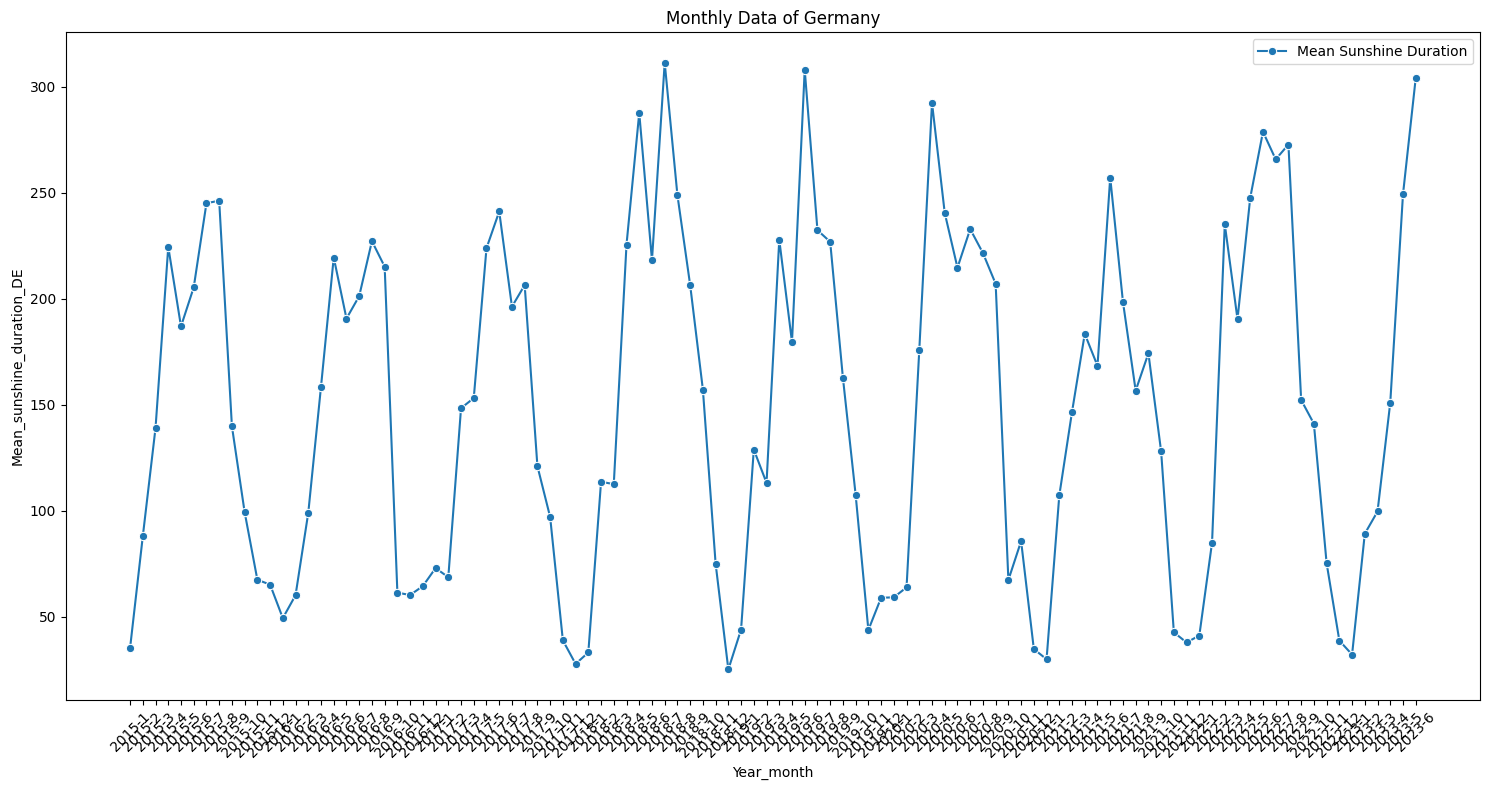

In [1159]:
plt.figure(figsize=(15,8))
sns.lineplot(data=data_df, y="Mean_sunshine_duration_DE", x="Year_month", label="Mean Sunshine Duration",  marker="o")\
    .set(title="Monthly Data of Germany")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

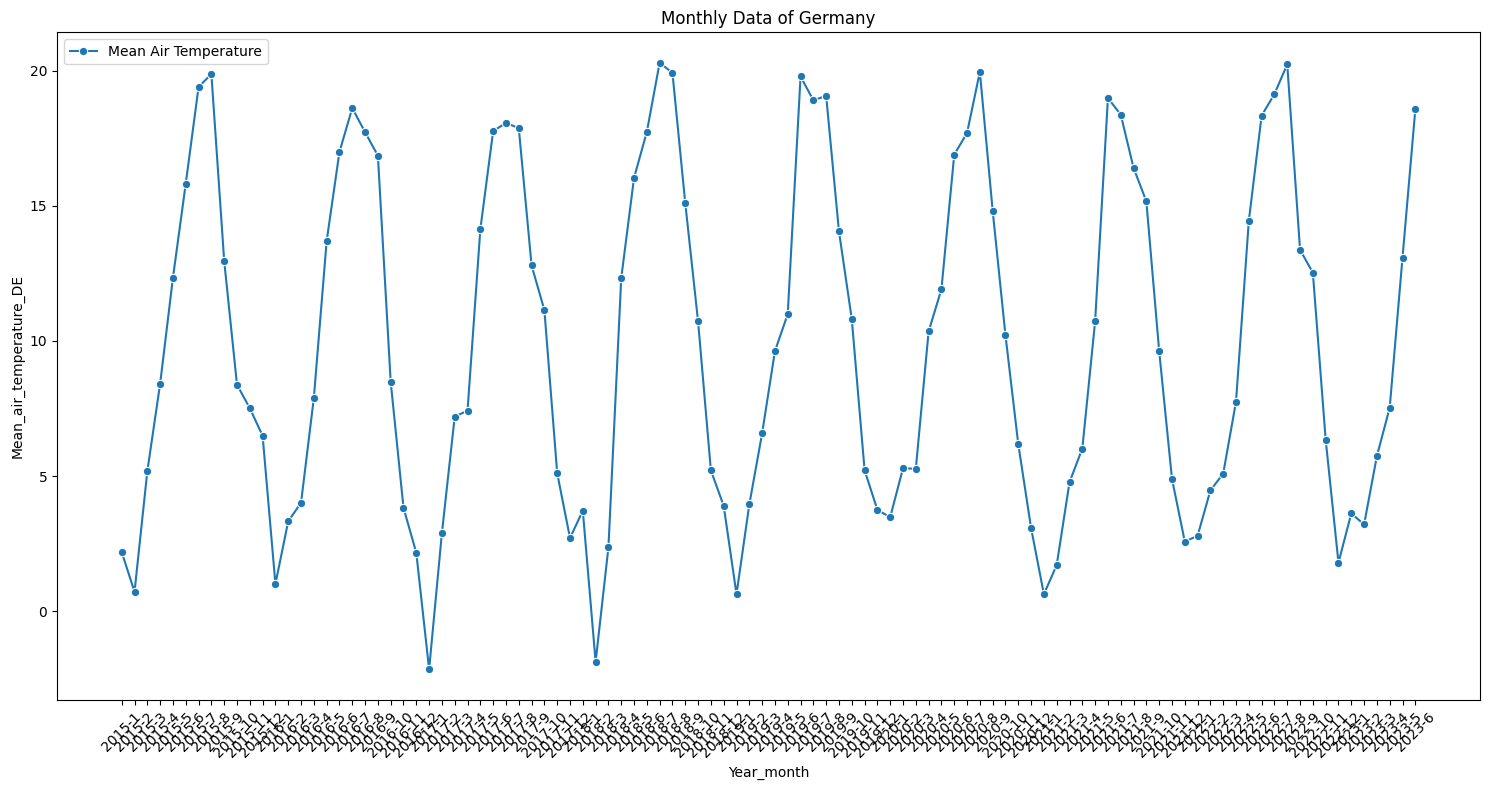

In [1161]:
plt.figure(figsize=(15,8))
sns.lineplot(data=data_df, y="Mean_air_temperature_DE", x="Year_month", label="Mean Air Temperature",  marker="o")\
    .set(title="Monthly Data of Germany")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#precipitation

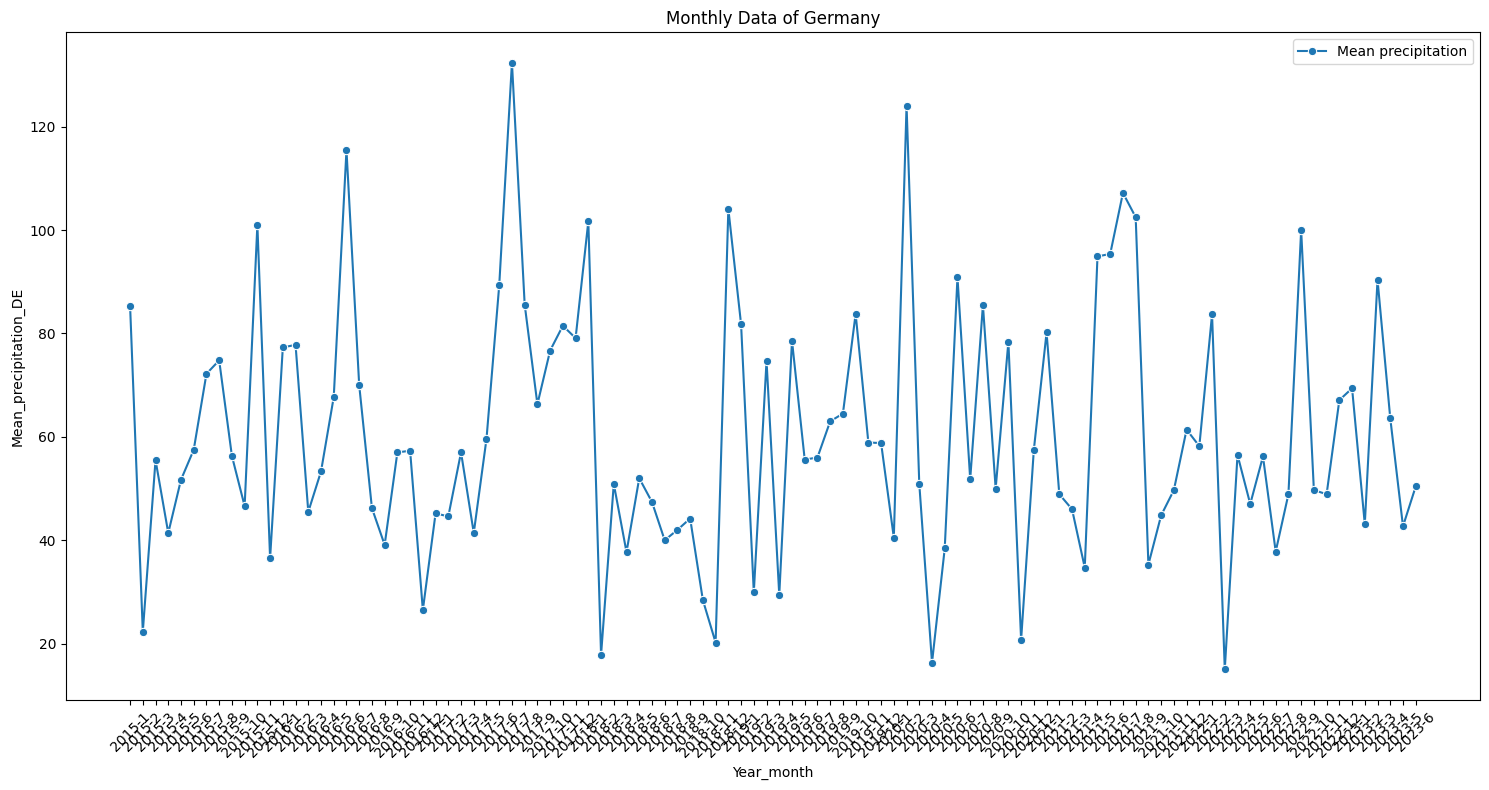

In [1160]:
plt.figure(figsize=(15,8))
sns.lineplot(data=data_df, y="Mean_precipitation_DE", x="Year_month", label="Mean precipitation",  marker="o")\
    .set(title="Monthly Data of Germany")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

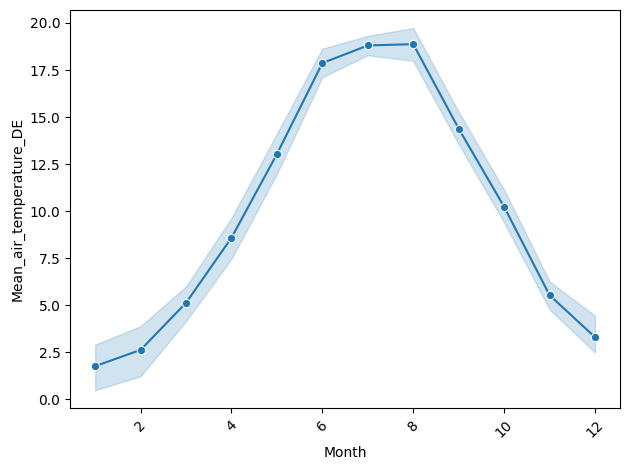

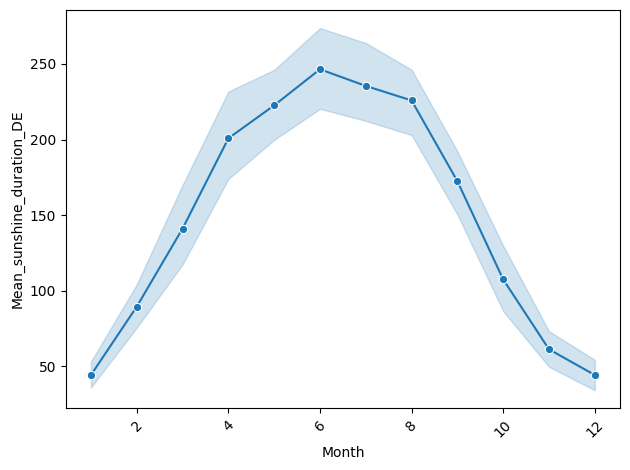

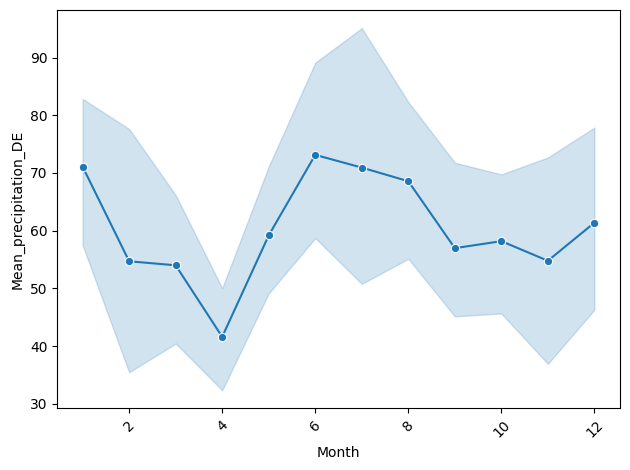

In [1113]:
simple_lineplot(data_df, 'Mean_air_temperature_DE', x="Month")
simple_lineplot(data_df, 'Mean_sunshine_duration_DE', x="Month")
simple_lineplot(data_df, 'Mean_precipitation_DE', x="Month")

In [ ]:
#plt.figure(figsize=(20,15))
#sns.lineplot(data=data_df, y="Mean_sunshine_duration_DE", x="Year_month", label="Mean Sunshine Duration")\
#    .set(title="Monthly Data of Germany")
#sns.lineplot(data=data_df, y="Mean_air_temperature_DE", x="Year_month", label="Mean Air Temperature DE")\
#    .set(title="Monthly Data of Germany")
#plt.xticks(rotation=45)
#plt.tight_layout()
#plt.show()

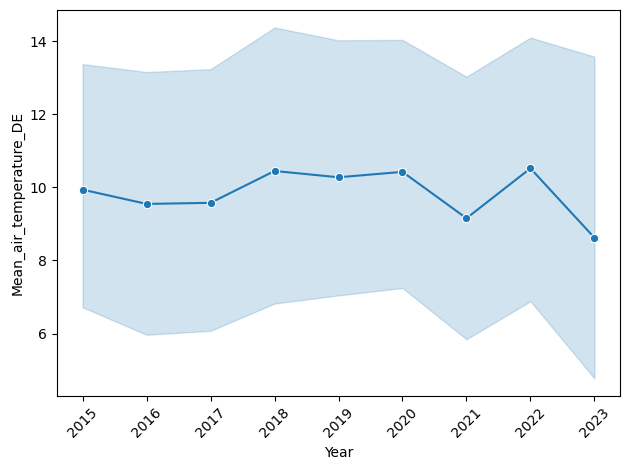

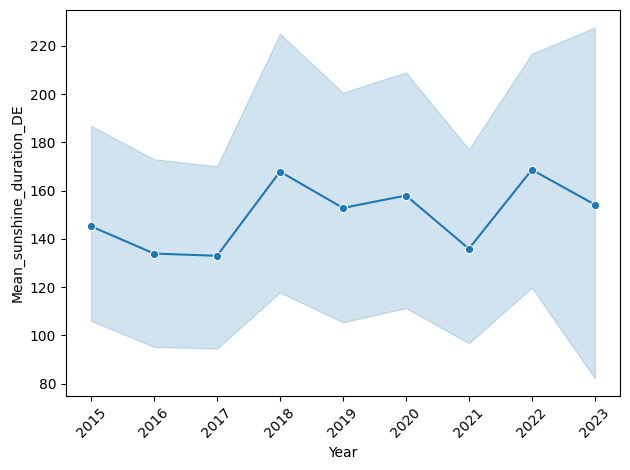

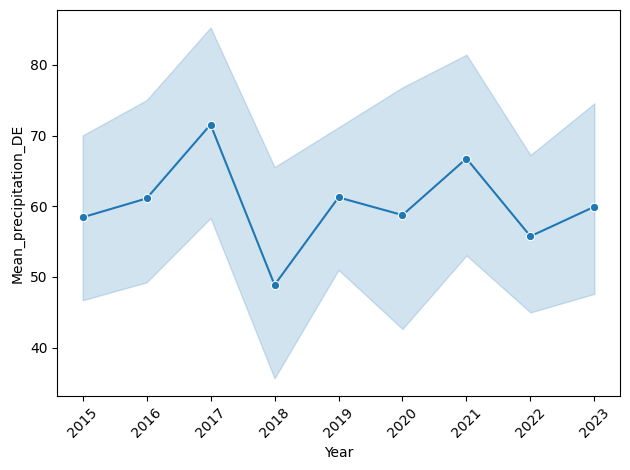

In [1158]:
simple_lineplot(data_df, 'Mean_air_temperature_DE', x="Year")
simple_lineplot(data_df, 'Mean_sunshine_duration_DE', x="Year")
simple_lineplot(data_df, 'Mean_precipitation_DE', x="Year")
